## Dataset Loading

In [39]:
import os
from pathlib import Path

from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()

api_key = os.getenv("ROBOFLOW_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [40]:
rf = Roboflow(api_key=api_key)

project = rf.workspace("lama-alghailan").project(
    "face-emotion-classification-ohlcy"
)

version = project.version(1)

dataset = version.download("folder")

print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset location: d:\AISoultionBootcam\Production_CV_Agent\training\Face-emotion-classification--1


## Classes Exploration

In [41]:
from pathlib import Path
from collections import Counter

DATA_DIR = Path("../training/Face-emotion-classification--1")

for split in ["train", "valid", "test"]:
    split_dir = DATA_DIR / split

    print(f"\n{split.upper()}")
    print("-" * 30)

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            images = [
                p for p in class_dir.iterdir()
                if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
            ]

            print(f"{class_dir.name}: {len(images)}")


TRAIN
------------------------------
angry: 130
happy: 190
neutral: 145
sad: 145
suprised: 139
tired: 141

VALID
------------------------------
angry: 35
happy: 56
neutral: 44
sad: 34
suprised: 41
tired: 45

TEST
------------------------------
angry: 25
happy: 34
neutral: 18
sad: 18
suprised: 17
tired: 15


## Image Exploration 

In [42]:
from pathlib import Path
from PIL import Image
import numpy as np

DATA_DIR = Path("..\\training\\Face-emotion-classification--1")

widths = []
heights = []

for split in ["train", "valid", "test"]:
    split_dir = DATA_DIR / split

    for image_path in split_dir.rglob("*"):
        if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            with Image.open(image_path) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)

print("Number of images:", len(widths))
print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Number of images: 1272
Average width: 957.5235849056604
Average height: 1219.0558176100628


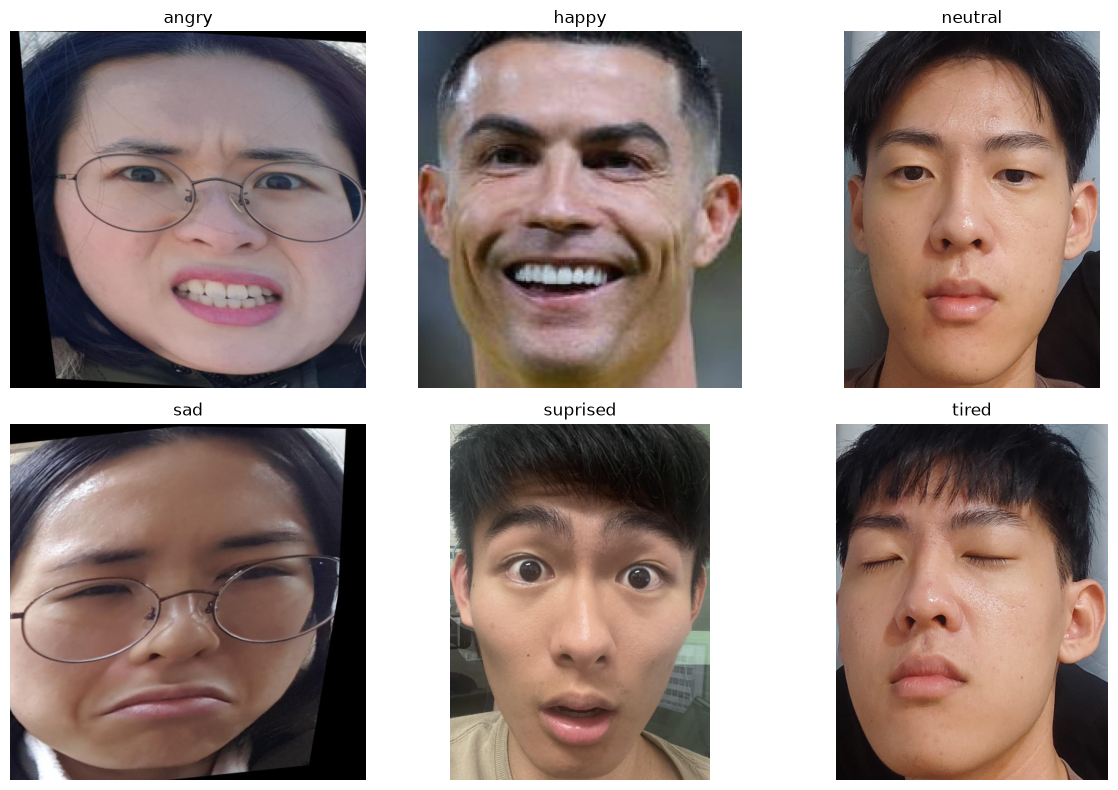

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import random

train_dir = DATA_DIR / "train"

classes = sorted([
    d.name for d in train_dir.iterdir()
    if d.is_dir()
])

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, class_name in zip(axes.ravel(), classes):
    class_dir = train_dir / class_name

    image_paths = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = random.choice(image_paths)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

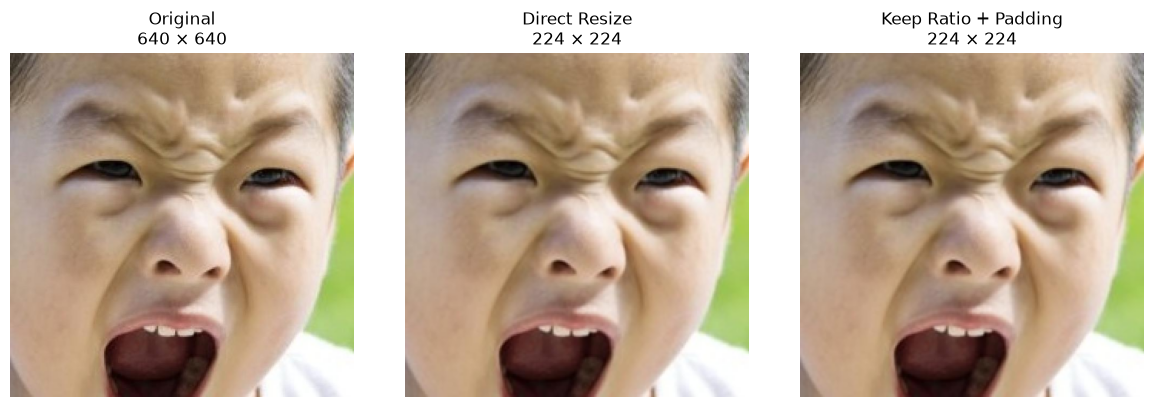

In [44]:
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# نختار أول صورة من train
DATA_DIR = Path("Face-emotion-classification--1/train")

image_path = next(DATA_DIR.rglob("*.jpg"))

# الصورة الأصلية
image = Image.open(image_path).convert("RGB")

# الطريقة 1: Resize مباشر
direct_resize = image.resize((224, 224))

# الطريقة 2: الحفاظ على Aspect Ratio + Padding
keep_ratio = ImageOps.contain(image, (224, 224))

padded = Image.new("RGB", (224, 224), (0, 0, 0))

x = (224 - keep_ratio.width) // 2
y = (224 - keep_ratio.height) // 2

padded.paste(keep_ratio, (x, y))

# عرض المقارنة
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(f"Original\n{image.width} × {image.height}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(direct_resize)
plt.title("Direct Resize\n224 × 224")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(padded)
plt.title("Keep Ratio + Padding\n224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
from PIL import Image
from pathlib import Path

from transforms import ResizeWithPadding


DATA_DIR = Path("Face-emotion-classification--1/train")

image_path = next(DATA_DIR.rglob("*.jpg"))

image = Image.open(image_path).convert("RGB")

transform = ResizeWithPadding(224)

result = transform(image)

print("Original size:", image.size)
print("Transformed size:", result.size)
image.show()


Original size: (640, 640)
Transformed size: (224, 224)


In [46]:
from transforms import get_train_transforms, get_eval_transforms

train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

train_result = train_transform(image)
eval_result = eval_transform(image)

print("Train output shape:", train_result.shape)
print("Eval output shape:", eval_result.shape)

Train output shape: torch.Size([3, 224, 224])
Eval output shape: torch.Size([3, 224, 224])


In [47]:
from pathlib import Path

from dataset import create_dataset
from transforms import get_train_transforms


data_dir = Path("Face-emotion-classification--1/train")

dataset = create_dataset(
    data_dir=data_dir,
    transform=get_train_transforms(),
)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Number of images: 890
Classes: ['angry', 'happy', 'neutral', 'sad', 'suprised', 'tired']
Class mapping: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'suprised': 4, 'tired': 5}


In [48]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Torch: 2.13.0+cpu
Torchvision: 0.28.0+cpu


In [49]:
from train import create_model

model = create_model()

print(model.classifier)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=6, bias=True)
)


In [52]:
from pathlib import Path
from train import create_dataloaders

DATA_DIR = Path("Face-emotion-classification--1")

train_loader, valid_loader, test_loader = create_dataloaders(DATA_DIR)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [51]:
import importlib
import train

importlib.reload(train)

print(hasattr(train, "create_dataloaders"))

True


In [53]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("لا يوجد GPU متاح — بيشتغل على CPU")

PyTorch version: 2.13.0+cpu
CUDA available: False
لا يوجد GPU متاح — بيشتغل على CPU
